# ABR dataset overview

A tour of the four input modalities the resistance models can use — built
through the single dataloader in `datasets/` — and exactly how each one is fed
to a model in the multi-modal setting.

| modality | what it is | shape per block | default encoder |
|---|---|---|---|
| **dna** | one-hot nucleotides, gene loci concatenated | `(N, 5, L)` — A,C,T,G,gap | CNN |
| **protein** | one-hot amino acids, one block per gene | `(N, 20, K)` | CNN (Transformer optional) |
| **biophysical** | MW / pI / hydrophobicity per residue, per gene | `(N, 3, K)` | CNN |
| **regulatory** | one-hot promoter/upstream regions (e.g. *fabG1*) | `(N, 5, L)` | CNN |

Each **block** becomes one branch of a late-fusion net (`models.MultiModalNet`):
the branch's encoder — a 1-D **CNN** or a patch **Transformer** — maps it to a
feature vector, all branches are concatenated, and a shared dense head emits the
per-drug R/S logit.

Runs on the real BIG-TB data when `USE_REAL = True`; otherwise on small
**synthetic** fixtures so it works anywhere.

In [ ]:
%matplotlib inline
import tempfile, warnings, gc, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')

from datasets import load_dataset, MODALITIES, DRUG_TO_LOCI, DRUG_TO_REGULATORY
from datasets.sequences import load_sequence_df, load_phenotype, numeric_labels
from models import ENCODERS, MultiModalNet
from bigtb_ref import REAL_GENOTYPE_DIR, REAL_PHENOTYPE_CSV, REAL_REGULATORY_DIR

USE_REAL       = True                 # <-- real BIG-TB data on Unity (pi_annagreen)
ALL_MODALITIES = list(MODALITIES)
DRUGS          = list(DRUG_TO_LOCI)   # all drugs in the benchmark
FOCUS          = 'ISONIAZID'          # drug shown block-by-block + in the wiring view
BRANCH_MODELS  = {}                   # per-modality encoder override, e.g. {'protein': 'transformer'}
DEFAULT_ENCODER = 'cnn'               # encoder for any modality not named above
print(f'{len(DRUGS)} drugs | modalities: {ALL_MODALITIES} | focus: {FOCUS}')

In [ ]:
# resolve the data source (real Unity paths, or a synthetic fixture set built once)
if USE_REAL:
    # regulatory now has its OWN dir: per-isolate WHO Table-22 promoter windows,
    # separate from the coding gene FASTAs in REAL_GENOTYPE_DIR.
    GENO, PHENO, REG = REAL_GENOTYPE_DIR, REAL_PHENOTYPE_CSV, REAL_REGULATORY_DIR
else:
    from fixtures import build_fixture_dataset
    genes = sorted({g for d in DRUGS for g in DRUG_TO_LOCI[d]})
    regions = sorted({r for d in DRUGS for r in DRUG_TO_REGULATORY.get(d, [])})
    GENO, PHENO = build_fixture_dataset(tempfile.mkdtemp(), genes=genes, drugs=DRUGS,
                                        n_isolates=200, n_codons=60, seed=0,
                                        regulatory_regions=regions)
    REG = GENO
print('source:', 'REAL' if USE_REAL else 'synthetic')

def blocks_of(data, modality):
    return [b for b in data.blocks if b.modality == modality]

## 1. Data health — every drug at a glance

One row per drug, straight from the aligned FASTAs + phenotype table (no model,
no one-hot — just counts). This is the first place to look when a drug
under-performs. Watch for:

- **`n_loci` / `genes`** — the loci we actually load and train on (the BIG-TB
  reference set, `DRUG_TO_LOCI`). **`n_loci` = 1** means the model sees one gene,
  so a mechanism in any other locus is invisible (red).
- **`who_t1` / `who_t2`** — how many candidate loci the **WHO 2023 catalogue
  (Table 21)** lists for the drug, first-order (tier 1) and second-order (tier 2).
  When `n_loci < who_t1` (orange) there are first-order candidates we're not yet
  feeding — a concrete lever to try.
- **small `n_labelled`** — too few labelled isolates to learn/measure well (< 500 = red).
- **extreme `R_frac`** — very few resistant (or susceptible) isolates; AUC gets
  noisy and the loss weighting is doing a lot of work (bold when < 0.12 or > 0.88).
- **high `missing_frac`** — most isolates have no phenotype for this drug, so the
  effective dataset is much smaller than `n`.

In [3]:
# lightweight per-drug stats (aligned strings only — avoids building 11 one-hot tensors)
from datasets.who_catalogue import TABLE_21
from datasets.regulatory import DRUG_NAME_TO_WHO

_pheno = load_phenotype(PHENO)
_seq_cache = {}
def _gene_series(gene):
    if gene not in _seq_cache:
        df, found = load_sequence_df(GENO, [gene])
        _seq_cache[gene] = df[gene] if found else None
    return _seq_cache[gene]

def _who_tiers(drug):
    """(#tier-1, #tier-2) candidate loci WHO Table 21 lists for this drug."""
    entry = TABLE_21.get(DRUG_NAME_TO_WHO.get(drug.upper()), {})
    return len(entry.get('tier1', [])), len(entry.get('tier2', []))

def drug_health(drug):
    # n_loci / genes = what we ACTUALLY load & train on (the BIG-TB reference loci)
    cols = {g: _gene_series(g) for g in DRUG_TO_LOCI[drug] if _gene_series(g) is not None}
    seq = pd.DataFrame(cols)
    iso = seq.index.intersection(_pheno.index)
    dna_len = int(sum(seq.loc[iso, g].dropna().str.len().max() for g in cols)) if len(iso) else 0
    y = numeric_labels(_pheno.loc[iso], drug)
    R, S, M = int((y == 0).sum()), int((y == 1).sum()), int((y == -1).sum())
    lab = R + S
    who_t1, who_t2 = _who_tiers(drug)   # loci WHO lists (first / second order)
    return {'drug': drug, 'n_loci': len(cols), 'genes': '+'.join(cols),
            'who_t1': who_t1, 'who_t2': who_t2,
            'n_labelled': lab, 'R': R, 'S': S, 'missing': M,
            'missing_frac': round(M / max(R + S + M, 1), 3),
            'R_frac': round(R / max(lab, 1), 3), 'dna_len': dna_len,
            'reg_candidates': len(DRUG_TO_REGULATORY.get(drug, []))}

health = pd.DataFrame([drug_health(d) for d in DRUGS]).set_index('drug')
health = health.sort_values('n_labelled')
gc.collect()

def _flag(row):
    st = {c: '' for c in row.index}
    if row['n_loci'] == 1:                    st['n_loci'] = 'background-color:#f00000'
    # loading fewer loci than WHO's first-order candidates -> untapped signal (watch)
    if row['n_loci'] < row['who_t1']:         st['who_t1'] = 'background-color:#fde0c8'
    if row['n_labelled'] < 500:               st['n_labelled'] = 'background-color:#f00000'
    if row['R_frac'] < 0.12 or row['R_frac'] > 0.88:
        st['R_frac'] = 'font-weight:bold; background-color:#fde0c8'
    if row['missing_frac'] > 0.5:             st['missing_frac'] = 'background-color:#f00000'
    return [st[c] for c in row.index]

(health.style
    .format({'R_frac': '{:.3f}', 'missing_frac': '{:.3f}'})
    .apply(_flag, axis=1)
    .set_caption('Per-drug data health (sorted by labelled isolates). '
                 'n_loci/genes = loci we train on (BIG-TB ref); who_t1/who_t2 = loci WHO Table 21 lists. '
                 'Orange = watch; red = likely limiting.'))

,n_loci,genes,who_t1,who_t2,n_labelled,R,S,missing,missing_frac,R_frac,dna_len,reg_candidates
drug,,,,,,,,,,,,
LEVOFLOXACIN,2,gyrB+gyrA,2,4,269,76,193,17673,0.985,0.283,4754,4
ETHIONAMIDE,3,inhA+ethA+ethR,4,4,2153,690,1463,15789,0.880,0.320,3398,5
MOXIFLOXACIN,2,gyrB+gyrA,2,4,2868,388,2480,15074,0.840,0.135,4754,4
KANAMYCIN,1,rrs,3,4,3576,703,2873,14366,0.801,0.197,1813,6
AMIKACIN,2,rrs+eis,3,4,3705,707,2998,14237,0.794,0.191,3234,5
CAPREOMYCIN,3,rrs+rrl+tlyA,2,6,3854,675,3179,14088,0.785,0.175,6153,5
STREPTOMYCIN,3,rpsL+rrs+gid,5,3,7682,2416,5266,10260,0.572,0.315,3453,5
PYRAZINAMIDE,1,pncA,3,5,12904,2131,10773,5038,0.281,0.165,1067,7
ETHAMBUTOL,3,embC+embA+embB,5,5,15111,2945,12166,2831,0.158,0.195,10099,7


## 2. Label composition per drug

Left: how many **labelled** isolates each drug has, split resistant / susceptible
(the number the model actually trains on — missing phenotypes excluded). Right:
the resistant fraction among labelled isolates, with a rough 'balanced-ish' band.

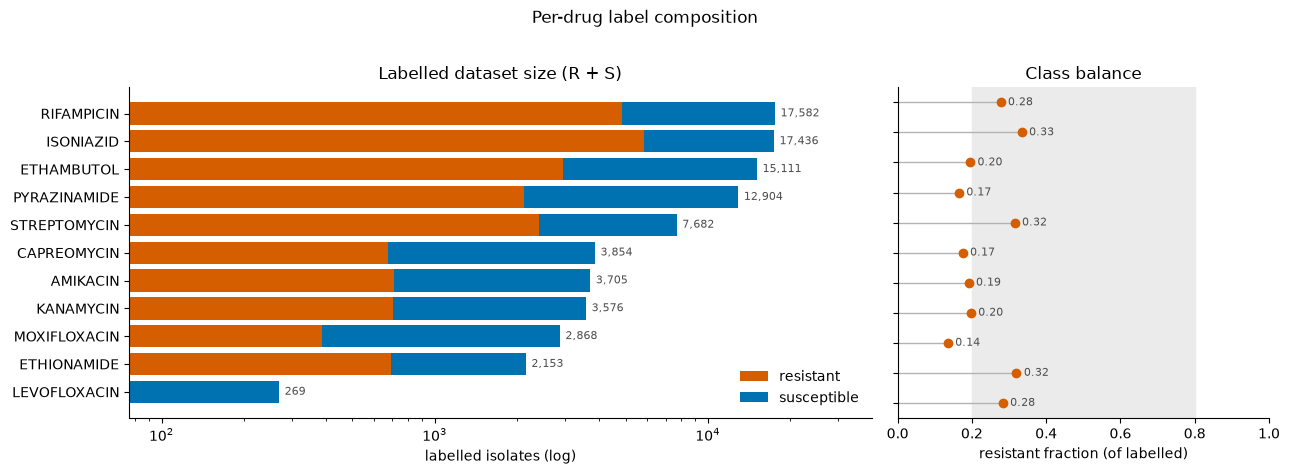

In [4]:
h = health.sort_values('n_labelled')
R_COL, S_COL, MISS = '#D55E00', '#0072B2', '#BDBDBD'   # Okabe-Ito (CVD-safe)
y = np.arange(len(h))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6),
                               gridspec_kw={'width_ratios': [2, 1]})

# left: labelled dataset size (R + S), log x so tiny drugs stay visible
axL.barh(y, h['R'], color=R_COL, label='resistant')
axL.barh(y, h['S'], left=h['R'], color=S_COL, label='susceptible')
axL.set_yticks(y, h.index)
axL.set_xscale('log')
axL.set_xlabel('labelled isolates (log)')
axL.set_title('Labelled dataset size (R + S)')
for yi, tot in zip(y, h['n_labelled']):
    axL.text(tot * 1.05, yi, f'{tot:,}', va='center', fontsize=8, color='0.3')
axL.legend(frameon=False, loc='lower right')
axL.margins(x=0.15)

# right: resistant fraction among labelled, with a balanced-ish band
axR.axvspan(0.2, 0.8, color='0.92', zorder=0)
axR.hlines(y, 0, h['R_frac'], color='0.7', lw=1)
axR.scatter(h['R_frac'], y, color=R_COL, zorder=3)
for yi, f in zip(y, h['R_frac']):
    axR.text(f + 0.02, yi, f'{f:.2f}', va='center', fontsize=8, color='0.3')
axR.set_yticks(y, [''] * len(y))
axR.set_xlim(0, 1)
axR.set_xlabel('resistant fraction (of labelled)')
axR.set_title('Class balance')

for ax in (axL, axR):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
fig.suptitle('Per-drug label composition', y=1.02)
plt.tight_layout(); plt.show()

## 3. Do the data issues line up with under-performance?

Our best config per drug (across everything in `results/experiments/`) minus the
published **BIG-TB SD-CNN** (Tasmin et al., Table 4, single-drug 1-D CNN on
one-hot DNA). Negative Δ = we trail the paper. If the drugs we trail on are also
the single-locus / tiny / imbalanced ones above, that points at data, not the model.

In [5]:
# BIG-TB SD-CNN baseline (Tasmin et al., Table 4 — single-drug, one-hot DNA)
BIGTB_SD = {'AMIKACIN':0.845,'CAPREOMYCIN':0.873,'ETHAMBUTOL':0.931,'ETHIONAMIDE':0.670,
            'ISONIAZID':0.917,'KANAMYCIN':0.849,'LEVOFLOXACIN':0.839,'MOXIFLOXACIN':0.886,
            'PYRAZINAMIDE':0.930,'RIFAMPICIN':0.977,'STREPTOMYCIN':0.911}

_proj = next((p for p in [Path('/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion'),
                          Path.cwd(), Path.cwd().parent]
              if (p / 'results/experiments').is_dir()), None)

perf = None
if _proj is not None:
    best = {}
    for csv in sorted((_proj / 'results/experiments').glob('*/summary.csv')):
        s = pd.read_csv(csv); s['drug'] = s['drug'].str.upper()
        for _, r in s.iterrows():
            best[r['drug']] = max(best.get(r['drug'], 0.0), float(r['test_auc']))
    perf = (pd.DataFrame({'our_best_auc': best})
              .assign(bigtb_sd=lambda d: d.index.map(BIGTB_SD))
              .dropna())
    perf['delta'] = (perf['our_best_auc'] - perf['bigtb_sd']).round(3)

if perf is None or perf.empty:
    print('No results/experiments summaries found — run experiments first to enable this view.')
    view = None
else:
    view = health.join(perf).sort_values('delta')
    display(view[['n_loci','genes','n_labelled','R_frac','missing_frac',
                  'our_best_auc','bigtb_sd','delta']]
            .style.format({'R_frac':'{:.3f}','missing_frac':'{:.3f}',
                           'our_best_auc':'{:.3f}','bigtb_sd':'{:.3f}','delta':'{:+.3f}'})
            .background_gradient(subset=['delta'], cmap='RdBu', vmin=-0.15, vmax=0.15)
            .set_caption('Data health joined to Δ AUC vs BIG-TB SD-CNN (sorted worst first).'))

,n_loci,genes,n_labelled,R_frac,missing_frac,our_best_auc,bigtb_sd,delta
drug,,,,,,,,
MOXIFLOXACIN,2,gyrB+gyrA,2868,0.135,0.840,0.789,0.886,-0.097
PYRAZINAMIDE,1,pncA,12904,0.165,0.281,0.894,0.930,-0.036
ETHAMBUTOL,3,embC+embA+embB,15111,0.195,0.158,0.926,0.931,-0.005
RIFAMPICIN,2,rpoB+rpoC,17582,0.277,0.020,0.977,0.977,-0.000
CAPREOMYCIN,3,rrs+rrl+tlyA,3854,0.175,0.785,0.874,0.873,+0.001
STREPTOMYCIN,3,rpsL+rrs+gid,7682,0.315,0.572,0.934,0.911,+0.023
ISONIAZID,2,inhA+katG,17436,0.334,0.028,0.952,0.917,+0.035
AMIKACIN,2,rrs+eis,3705,0.191,0.794,0.885,0.845,+0.040
ETHIONAMIDE,3,inhA+ethA+ethR,2153,0.320,0.880,0.761,0.670,+0.091


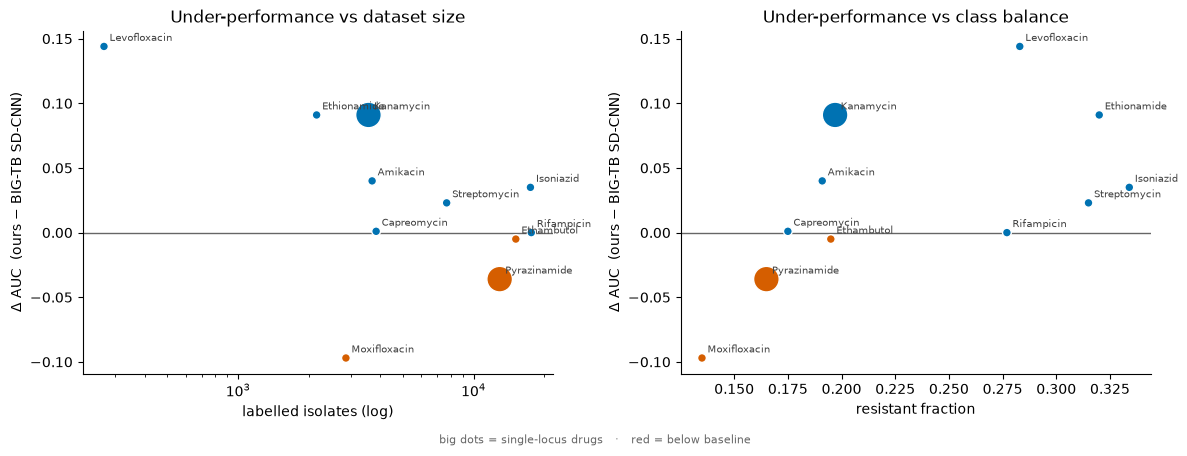

In [6]:
if view is not None:
    POS, NEG = '#0072B2', '#D55E00'
    fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.4))
    for ax, x, xlabel, logx in [(a0, 'n_labelled', 'labelled isolates (log)', True),
                                (a1, 'R_frac', 'resistant fraction', False)]:
        colors = [POS if d >= 0 else NEG for d in view['delta']]
        sizes = 40 + 300 * (view['n_loci'] == 1)   # single-locus drugs drawn big
        ax.scatter(view[x], view['delta'], c=colors, s=sizes, edgecolor='white', zorder=3)
        ax.axhline(0, color='0.4', lw=1)
        for d, xv, yv in zip(view.index, view[x], view['delta']):
            ax.annotate(d.title(), (xv, yv), fontsize=7, color='0.25',
                        xytext=(4, 4), textcoords='offset points')
        if logx: ax.set_xscale('log')
        ax.set_xlabel(xlabel); ax.set_ylabel('Δ AUC  (ours − BIG-TB SD-CNN)')
        for s in ('top', 'right'): ax.spines[s].set_visible(False)
    a0.set_title('Under-performance vs dataset size')
    a1.set_title('Under-performance vs class balance')
    fig.text(0.5, -0.02, 'big dots = single-locus drugs   ·   red = below baseline',
             ha='center', fontsize=8, color='0.4')
    plt.tight_layout(); plt.show()

## 4. One drug, every modality — the feature blocks

What the loader produces for **`FOCUS`**: one row per feature block. Each block is
one branch of the model. `regulatory` only appears where a promoter FASTA exists
(e.g. *fabG1* for isoniazid); otherwise it is dropped and reported below.

In [7]:
data = load_dataset(FOCUS, ALL_MODALITIES, GENO, PHENO, regulatory_dir=REG)
print(f'{FOCUS}: {data.n} isolates | class counts {data.class_counts()}')
print(f'modalities used: {data.modalities}   dropped: {data.dropped}')
pd.DataFrame([{'block': b.name, 'modality': b.modality, 'channels': b.channels,
               'length': b.length, 'note': b.note} for b in data.blocks])

ISONIAZID: 17942 isolates | class counts {'R': 5825, 'S': 11611, 'missing': 506}
modalities used: ['dna', 'protein', 'biophysical', 'regulatory']   dropped: []


,block,modality,channels,length,note
0,dna,dna,5,3398,genes concatenated: inhA+katG
1,protein:inhA,protein,20,269,"gene inhA, translated + left-aligned"
2,protein:katG,protein,20,432,"gene katG, translated + left-aligned"
3,biophysical:inhA,biophysical,3,269,"gene inhA, z-scored per property"
4,biophysical:katG,biophysical,3,432,"gene katG, z-scored per property"
5,regulatory:fabG1,regulatory,5,844,WHO candidate locus fabG1 (no Table 22 upstrea...


## 5. What goes into what model (multi-modal wiring)

The exact graph for the current `FOCUS` + `BRANCH_MODELS`: every block is sent to
its own encoder (**CNN** = local motif detector, `models.CNNEncoder`; **Transformer** = long-range patch-attention, `models.TransformerEncoder`), the
resulting feature vectors are concatenated, and a shared `DenseHead(256→256)`
produces the single R/S logit. Set `BRANCH_MODELS = {'protein': 'transformer'}`
in the config cell to route the protein branches through the Transformer instead.

In [8]:
def wiring(data, branch_models=None, default_encoder='cnn'):
    branch_models = branch_models or {}
    rows = []
    for b in data.blocks:
        etype = branch_models.get(b.modality, default_encoder)
        c, l = b.spec()
        enc = ENCODERS[etype](c, l)                     # actually build it -> real out_features
        rows.append({'block': b.name, 'modality': b.modality, 'input (C×L)': f'{c}×{l}',
                     'encoder': etype, 'encoder_class': type(enc).__name__,
                     'out_features': enc.out_features})
    tbl = pd.DataFrame(rows)
    return tbl, int(tbl['out_features'].sum())

def show_wiring(data, branch_models, default_encoder):
    tbl, fused = wiring(data, branch_models, default_encoder)
    display(tbl)
    w = max(tbl['block'].str.len().max(), len('concat all branches'))
    print(f'\n{data.drug}  ·  modality set: {data.modality_tag()}  ·  '
          f'encoders: {branch_models or "all " + default_encoder}\n')
    for _, r in tbl.iterrows():
        print(f"  {r['block']:<{w}}  {r['input (C×L)']:>11}  --{r['encoder']:<11}>  {r['out_features']:>6} feat")
    print(f"  {'-' * (w + 34)}")
    print(f"  {'concat all branches':<{w}}  {'':>11}                {fused:>6} feat")
    print(f"  -> DenseHead(256 -> 256) -> 1 logit   ({data.drug} R/S)")
    return fused

_ = show_wiring(data, BRANCH_MODELS, DEFAULT_ENCODER)

,block,modality,input (C×L),encoder,encoder_class,out_features
0,dna,dna,5×3398,cnn,CNNEncoder,12064
1,protein:inhA,protein,20×269,cnn,CNNEncoder,960
2,protein:katG,protein,20×432,cnn,CNNEncoder,1536
3,biophysical:inhA,biophysical,3×269,cnn,CNNEncoder,960
4,biophysical:katG,biophysical,3×432,cnn,CNNEncoder,1536
5,regulatory:fabG1,regulatory,5×844,cnn,CNNEncoder,2976



ISONIAZID  ·  modality set: dna+protein+biophysical+regulatory  ·  encoders: all cnn

  dna                       5×3398  --cnn        >   12064 feat
  protein:inhA              20×269  --cnn        >     960 feat
  protein:katG              20×432  --cnn        >    1536 feat
  biophysical:inhA           3×269  --cnn        >     960 feat
  biophysical:katG           3×432  --cnn        >    1536 feat
  regulatory:fabG1           5×844  --cnn        >    2976 feat
  -----------------------------------------------------
  concat all branches                              20032 feat
  -> DenseHead(256 -> 256) -> 1 logit   (ISONIAZID R/S)


The same drug with the protein branches swapped to a Transformer — note how the
per-branch `out_features` (and therefore the fused width into the head) change,
while the CNN branches are untouched:

In [9]:
_ = show_wiring(data, {'protein': 'transformer'}, 'cnn')

,block,modality,input (C×L),encoder,encoder_class,out_features
0,dna,dna,5×3398,cnn,CNNEncoder,12064
1,protein:inhA,protein,20×269,transformer,TransformerEncoder,64
2,protein:katG,protein,20×432,transformer,TransformerEncoder,64
3,biophysical:inhA,biophysical,3×269,cnn,CNNEncoder,960
4,biophysical:katG,biophysical,3×432,cnn,CNNEncoder,1536
5,regulatory:fabG1,regulatory,5×844,cnn,CNNEncoder,2976



ISONIAZID  ·  modality set: dna+protein+biophysical+regulatory  ·  encoders: {'protein': 'transformer'}

  dna                       5×3398  --cnn        >   12064 feat
  protein:inhA              20×269  --transformer>      64 feat
  protein:katG              20×432  --transformer>      64 feat
  biophysical:inhA           3×269  --cnn        >     960 feat
  biophysical:katG           3×432  --cnn        >    1536 feat
  regulatory:fabG1           5×844  --cnn        >    2976 feat
  -----------------------------------------------------
  concat all branches                              17664 feat
  -> DenseHead(256 -> 256) -> 1 logit   (ISONIAZID R/S)


## 6. Modality features (for the write-up)

### DNA one-hot — what the CNN actually sees
The first stretch of one isolate's one-hot matrix. Each column is a position; the
lit row is the base (or the gap channel for an alignment gap).

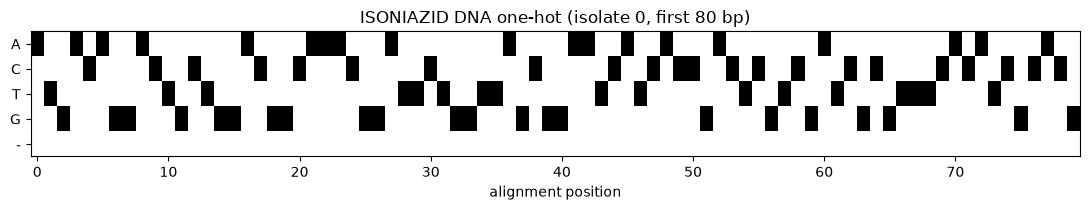

In [10]:
dna_block = blocks_of(data, 'dna')[0]
dna = dna_block.array                     # (N, 5, L)
channels = dna_block.channel_names
window = dna[0, :, :80]
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.imshow(window, aspect='auto', cmap='Greys', interpolation='nearest')
ax.set_yticks(range(len(channels))); ax.set_yticklabels(channels)
ax.set_xlabel('alignment position')
ax.set_title(f'{FOCUS} DNA one-hot (isolate 0, first 80 bp)')
plt.tight_layout(); plt.show()

### Sequence length & gap content
Per-isolate gap fraction (share of alignment columns that are gaps) — a proxy for
indels / partial coverage across the population.

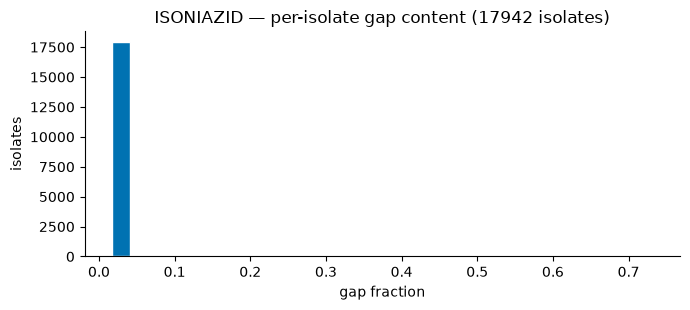

In [11]:
occupied = dna.sum(axis=1) > 0            # (N, L) columns with any base or gap
gap_frac = dna[:, channels.index('-'), :].sum(axis=1) / np.clip(occupied.sum(axis=1), 1, None)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(gap_frac, bins=30, color='#0072B2', edgecolor='white')
ax.set_xlabel('gap fraction'); ax.set_ylabel('isolates')
ax.set_title(f'{FOCUS} — per-isolate gap content ({data.n} isolates)')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Biophysical traits
Distribution of the three z-scored per-residue properties (over all residues in
all isolates) for the first gene's biophysical block.

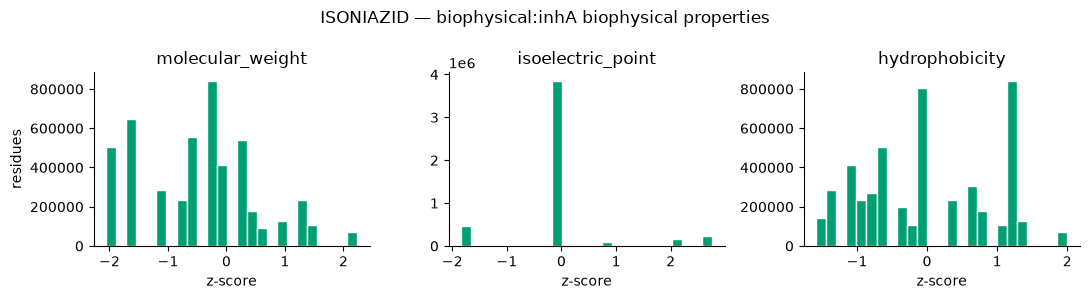

In [12]:
bio_block = blocks_of(data, 'biophysical')[0]
bio = bio_block.array                      # (N, 3, K)
resid = (bio != 0).any(axis=1)             # (N, K) real residues (not padding)
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for p, (name, ax) in enumerate(zip(bio_block.channel_names, axes)):
    ax.hist(bio[:, p, :][resid], bins=25, color='#009E73', edgecolor='white')
    ax.set_title(name); ax.set_xlabel('z-score')
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
axes[0].set_ylabel('residues')
fig.suptitle(f'{FOCUS} — {bio_block.name} biophysical properties')
plt.tight_layout(); plt.show()

### Protein lengths
Translated protein length per isolate for each gene (translation stops at the
first stop codon, so nonsense truncations show up as short proteins).

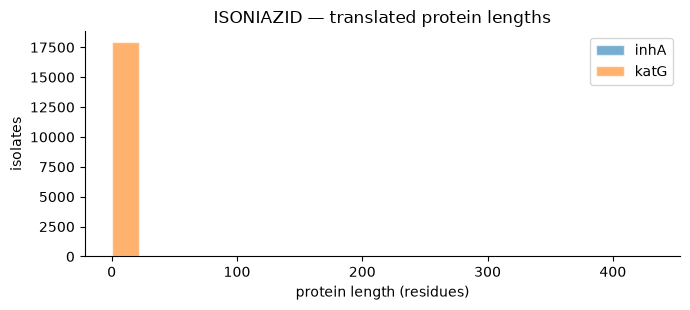

In [13]:
prot_blocks = blocks_of(data, 'protein')
fig, ax = plt.subplots(figsize=(7, 3.2))
for b in prot_blocks:
    lengths = ((b.array != 0).any(axis=1)).sum(axis=1)   # residues per isolate
    ax.hist(lengths, bins=20, alpha=0.6, label=b.name.split(':')[1], edgecolor='white')
ax.set_xlabel('protein length (residues)'); ax.set_ylabel('isolates')
ax.set_title(f'{FOCUS} — translated protein lengths'); ax.legend()
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

---
### Notes for the meeting

- **Data health first (§1–3).** The drugs we trail BIG-TB on are the ones with a
  data limitation, not a model one: *pyrazinamide* is **single-locus** (`pncA`
  only), *moxifloxacin* has very few resistant isolates and huge missingness, and
  *levofloxacin* has only a few hundred labelled isolates. Adding loci / labels is
  the lever, not architecture.
- **Modalities (§4).** DNA is the gene loci concatenated; protein & biophysical
  are per-gene blocks (one branch each); regulatory loads WHO-catalogue promoter
  regions where a FASTA exists (*fabG1* for INH/ETO, *eis* for KAN) and is dropped
  otherwise.
- **Wiring (§5).** Late fusion with a per-modality encoder choice — `CNN` for
  local motifs, `Transformer` for long-range residue interactions — concatenated
  into one dense head. `out_features` are computed from the real encoders, so the
  fused width shown is exactly what the head receives.
- Biophysical property values are standard published tables (z-scored), a stand-in
  until Kulkarni et al.'s exact table is confirmed (see `biophysical_properties_rdkit.ipynb`).
- Set `USE_REAL = False` for the synthetic fixtures (shapes/coverage only —
  performance numbers there are meaningless by construction).